#Task 4: Quantization Error at Different Bit Widths


##Objective

Study how quantization error changes as the number of bits is reduced from 8 to 6 to 4.


Bit width determines the number of integer values available to represent floating-point data during quantization. A higher bit width provides more representable levels and generally produces lower quantization error, while a lower bit width reduces memory usage but increases information loss.

In symmetric quantization:

- The zero point is always 0.
- The quantization range depends on the bit width.
- The scale is computed using the maximum absolute value of the tensor.

The quantization parameters are:

- q_min = -(2^(b-1)) + 1
- q_max = (2^(b-1)) - 1
- scale = max(|x_min|, |x_max|) / q_max

In [2]:
#import the req libs

import numpy as np
import matplotlib.pyplot as plt

In [4]:
tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [5]:
def quantize_at_bitwidth(tensor, bits):

    # Symmetric quantization at a given bit width
    # Return: (quantized_tensor, dequantized_tensor, scale)

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1

    max_abs = np.max(np.abs(tensor))

    scale = max_abs / q_max

    quantized = np.round(tensor / scale)
    quantized = np.clip(quantized, q_min, q_max)
    quantized = quantized.astype(np.int32)

    dequantized = quantized.astype(np.float32) * scale

    return quantized, dequantized, scale

In [6]:
def calculate_errors(original, dequantized):

    error = original - dequantized
    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    max_error = np.max(np.abs(error))

    return mae, mse, max_error

In [8]:
results = []

for bits in [8, 6, 4]:

    q_min = -(2 ** (bits - 1)) + 1
    q_max = (2 ** (bits - 1)) - 1
    levels = q_max - q_min + 1

    quantized, dequantized, scale = quantize_at_bitwidth(
        tensor,
        bits
    )

    mae, mse, max_error = calculate_errors(
        tensor,
        dequantized
    )

    results.append({
        "Bits": bits,
        "q_min": q_min,
        "q_max": q_max,
        "Levels": levels,
        "Scale": scale,
        "MAE": mae,
        "MSE": mse,
        "Max Error": max_error,
        "Dequantized": dequantized
    })


    print(f"{bits}-Bit Quantization")

    print("Scale:", scale)

    print("\nQuantized Tensor:")
    print(quantized)

    print("\nDequantized Tensor:")
    print(dequantized)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("Maximum Error:", max_error)

    print("---------------------------------------------------------------------------")
    print()

8-Bit Quantization
Scale: 0.018897638

Quantized Tensor:
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]

Dequantized Tensor:
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]

MAE: 0.0037007749
MSE: 2.1638e-05
Maximum Error: 0.007874012
---------------------------------------------------------------------------

6-Bit Quantization
Scale: 0.077419356

Quantized Tensor:
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]

Dequantized Tensor:
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]

MAE: 0.015161285
MSE: 0.00036316324
Maximum Error: 0.032258064
---------------------------------------------------------------------------

4-Bit Quantization
Scale: 0.34285715

Quantized Tensor:
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]

Dequantized Tensor:
[[-1.7142857  -1.0285715   0.          0.6857143   1.3714286 ]
 [-2.4        -0.34285715  0.

| Bits | q_min | q_max | Levels | Scale | MAE | MSE | Max Error |
|------|------:|------:|-------:|------:|------:|------:|------:|
| 8 | -127 | 127 | 255 | 0.018898 | 0.003701 | 0.00002164 | 0.007874 |
| 6 | -31 | 31 | 63 | 0.077419 | 0.015161 | 0.00036316 | 0.032258 |
| 4 | -7 | 7 | 15 | 0.342857 | 0.067143 | 0.00712245 | 0.142857 |

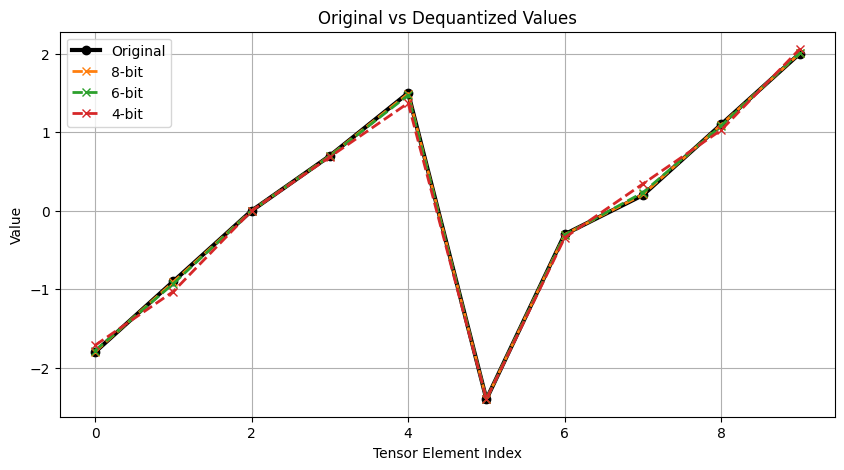

In [10]:
plt.figure(figsize=(10,5))

original = tensor.flatten()

plt.plot(
    original,
    color='black',
    linewidth=3,
    marker='o',
    label='Original'
)

colors = ['tab:orange', 'tab:green', 'tab:red']

for color, result in zip(colors, results):
    plt.plot(
        result["Dequantized"].flatten(),
        linestyle='--',
        marker='x',
        linewidth=2,
        color=color,
        label=f'{result["Bits"]}-bit'
    )

plt.title("Original vs Dequantized Values")
plt.xlabel("Tensor Element Index")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

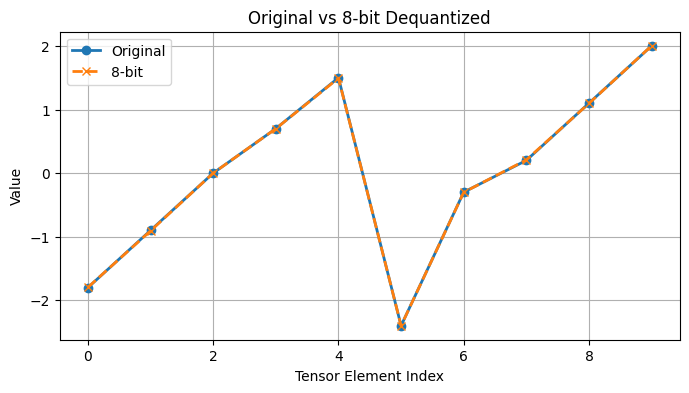

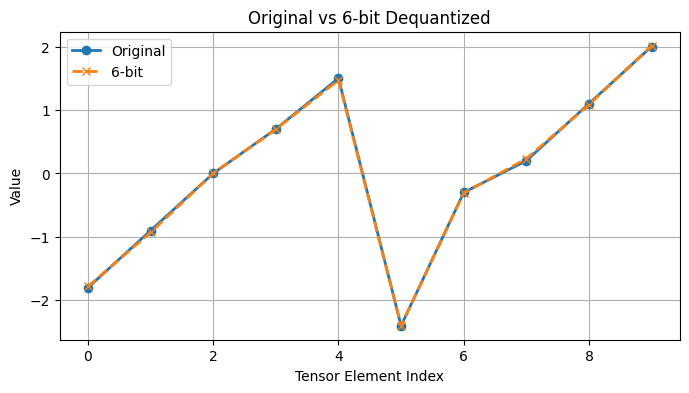

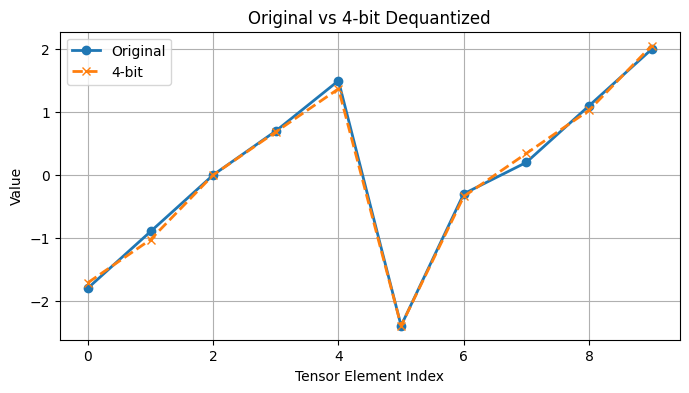

In [11]:
for result in results:

    plt.figure(figsize=(8,4))

    plt.plot(
        tensor.flatten(),
        marker='o',
        linewidth=2,
        label='Original'
    )

    plt.plot(
        result["Dequantized"].flatten(),
        marker='x',
        linestyle='--',
        linewidth=2,
        label=f'{result["Bits"]}-bit'
    )

    plt.title(f'Original vs {result["Bits"]}-bit Dequantized')

    plt.xlabel("Tensor Element Index")
    plt.ylabel("Value")

    plt.grid(True)
    plt.legend()

    plt.show()

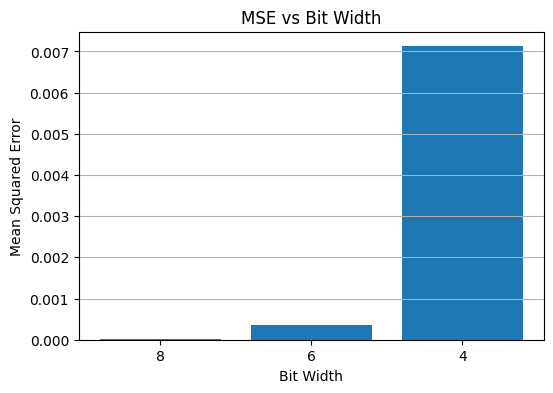

In [12]:
bit_widths = [r["Bits"] for r in results]
mse_values = [r["MSE"] for r in results]
plt.figure(figsize=(6,4))
plt.bar(
    [str(b) for b in bit_widths],
    mse_values
)

plt.title("MSE vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Mean Squared Error")
plt.grid(axis='y')
plt.show()

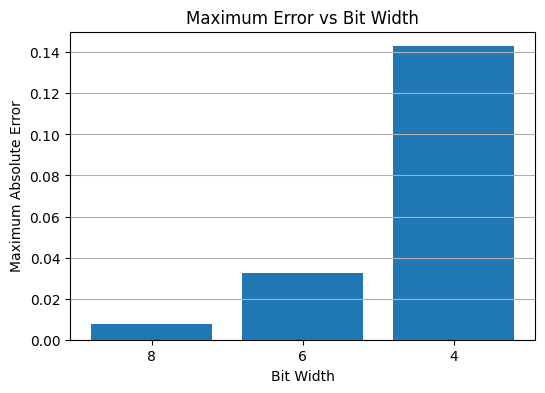

In [14]:
max_errors = [r["Max Error"] for r in results]
plt.figure(figsize=(6,4))

plt.bar(
    [str(b) for b in bit_widths],
    max_errors
)

plt.title("Maximum Error vs Bit Width")
plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")
plt.grid(axis='y')
plt.show()

## Observations

- As the bit width decreased from 8-bit to 6-bit and 4-bit, the quantization scale increased because fewer integer levels were available.
- The 8-bit quantization produced the smallest MAE, MSE, and Maximum Error, indicating the highest reconstruction accuracy.
- The 6-bit quantization introduced moderate reconstruction error while still preserving the overall shape of the tensor.
- The 4-bit quantization showed the largest reconstruction error due to its limited number of representable levels.
- From the overlay graph, the 8-bit dequantized values almost overlap the original tensor, while the 4-bit values show the greatest deviation.